# Writing your first program, step by step

This notebook builds one small program from nothing, one line at a time, and explains
what each line does. **The question here is not the homework question**: we roll a die.
The homework asks about other distributions, but the *shape* of the program is the same,
and that shape is the thing worth learning.

How to use it: run each cell with **Shift+Enter**, in order, from the top. Then change a
number and run the cell again. Breaking a cell and fixing it is how you learn what it does;
you cannot damage anything here.

The program we are going to write has five steps:

1. make the list of sample sizes;
2. make room to store one number for each sample size;
3. for each sample size: draw that many random numbers, average them, store the average;
4. plot the stored averages against the sample size;
5. (in the homework) do the same for a second distribution.

## Step 0: the setup

Two libraries: `numpy` for numbers and `matplotlib` for plots. We also make a random
number generator with a fixed seed, so the numbers below are the same every time.
Run this cell first; everything later depends on it.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)   # random number generator, seed 0
print("ready")

ready


## Step 1: draw random numbers

`rng.integers(1, 7, size=10)` rolls a die ten times. Note the `7`: the upper end is
**left out**, so this gives the numbers 1 to 6.

Run the cell twice. The numbers change, because each call continues the stream of random
numbers. Re-running the setup cell above resets it.

In [2]:
rolls = rng.integers(1, 7, size=10)
print(rolls)

[6 4 4 2 2 1 1 1 2 5]


## Step 2: average them

`np.mean` adds the numbers up and divides by how many there are. A fair die has mean
$(1+2+3+4+5+6)/6 = 3.5$. Ten rolls land near it, ten thousand rolls land very near it:
that is the law of large numbers, and it is what the homework problem is about.

In [3]:
print("average of these 10 rolls:", np.mean(rolls))
print("average of 10000 rolls:   ", np.mean(rng.integers(1, 7, size=10000)))
print("true mean of a fair die:  ", (1 + 2 + 3 + 4 + 5 + 6) / 6)

average of these 10 rolls: 2.8
average of 10000 rolls:    3.5058
true mean of a fair die:   3.5


## Step 3: the list of sample sizes

We want to watch the average settle down as the sample size grows, so we need a list of
sample sizes. `np.arange(10, 501, 10)` counts 10, 20, 30, ..., 500. Like `integers`, it
leaves the end point out, which is why it says 501 and not 500.

In [4]:
nvals = np.arange(10, 501, 10)
print(nvals[:5], "...", nvals[-1])
print("how many sample sizes:", nvals.size)

[10 20 30 40 50] ... 500
how many sample sizes: 50


## Step 4: room to store the results

One average per sample size, so we need 50 slots. `np.zeros` makes them, filled with
zeros for now. This is the step beginners most often skip, and then have nowhere to put
the results.

In [5]:
avg = np.zeros(nvals.size)
print(avg[:5], "...")
print("how many slots:", avg.size)

[0. 0. 0. 0. 0.] ...
how many slots: 50


## Step 5: the loop

Now do Step 1 and Step 2 once for every sample size, and put each answer in its slot.

`enumerate` hands us two things at a time: `k` counts the slots 0, 1, 2, ..., and `n` is
the sample size itself, 10, 20, 30, .... So `avg[k] = ...` fills slot `k`, and
`size=n` draws `n` numbers. Everything indented under the `for` line happens once per
sample size.

In [6]:
for k, n in enumerate(nvals):
    rolls = rng.integers(1, 7, size=n)
    avg[k] = np.mean(rolls)

print("the first five averages:", avg[:5])

the first five averages: [3.4        3.65       3.86666667 3.475      3.96      ]


## Step 6: plot it

`plt.plot(x, y)` draws y against x. The dashed line at 3.5 is there to compare against;
a plot without labels is not finished, so give it axis labels and a legend.

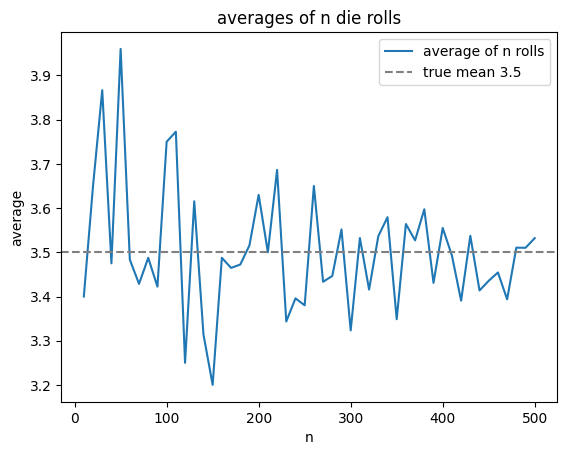

In [7]:
plt.plot(nvals, avg, label="average of n rolls")
plt.axhline(3.5, color="gray", linestyle="--", label="true mean 3.5")
plt.xlabel("n")
plt.ylabel("average")
plt.title("averages of n die rolls")
plt.legend()
plt.show()

The averages bounce around for small `n` and settle toward 3.5 as `n` grows, and the
bouncing shrinks. Try `np.arange(10, 5001, 10)` in Step 3 and run the cells again.

## Step 7: the whole program

Here are all the steps in one cell. This is what the finished script looks like, and it is
about ten lines. `plt.savefig` writes the figure to a file, which is how you get a picture
into your homework PDF; it has to come **before** `plt.show()`.

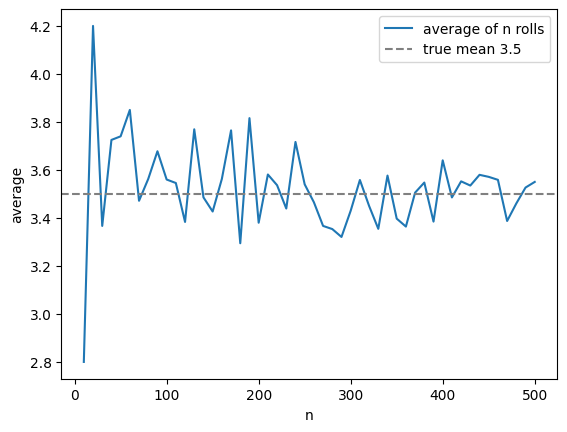

In [8]:
rng = np.random.default_rng(0)          # 0. setup

nvals = np.arange(10, 501, 10)          # 1. the sample sizes
avg = np.zeros(nvals.size)              # 2. room for one average each

for k, n in enumerate(nvals):           # 3. for each sample size ...
    rolls = rng.integers(1, 7, size=n)  #    draw that many numbers
    avg[k] = np.mean(rolls)             #    average them, store the average

plt.plot(nvals, avg, label="average of n rolls")   # 4. plot
plt.axhline(3.5, color="gray", linestyle="--", label="true mean 3.5")
plt.xlabel("n")
plt.ylabel("average")
plt.legend()
plt.savefig("hw01-die.png", dpi=150)         # save before showing
plt.show()

## What to change for your own problem

* **A different distribution.** Change only the line that draws the numbers. The
  assignment lists the function to use in MATLAB, Python and R, and `random_numbers.py`
  in this folder shows several of them side by side.
* **Different sample sizes.** Change the `np.arange` line in Step 3.
* **Two distributions in one figure.** Keep two result arrays, fill both inside the same
  loop, and call `plt.plot` twice before `plt.show()`.
* **Writing a script instead of a notebook.** Copy the cell from Step 7 into a file
  called `something.py` and run `python3 something.py`. That file is what you upload to
  Gradescope; a notebook is fine for working things out, but hand in the code.

## When something goes wrong

* `NameError: name 'np' is not defined` — you have not run the setup cell in this session.
  Run the cells above, or use *Kernel > Restart and Run All*.
* `IndexError` in the loop — `avg` is smaller than the number of sample sizes. Re-run
  Step 4 after changing Step 3.
* **The plot does not appear** — make sure the cell ends with `plt.show()`.
* **The numbers change every run** — expected: each draw continues the stream. Re-run the
  setup cell to start over from the seed.
* **Nothing makes sense any more** — cells were probably run out of order. *Kernel >
  Restart and Run All* runs everything from the top, in order.
* **Read errors from the bottom up.** The last line says what went wrong; the line above
  usually says which line of yours caused it.

## Next

`plot_function`, `random_numbers`, `sample_average` and `mean_vs_n` in this folder show
the same pieces as plain scripts, in four languages, and `mean_vs_n` is closest to what
the homework asks for. If you are stuck for more than ten or fifteen minutes, bring the
code that does not work to office hours or recitation.